### 1. Introduction

This notebook explores the Telco Customer Churn dataset to understand customer behavior and identify key factors related to customer churn.

The main goals of this exploratory data analysis are:

- Understand the overall churn distribution
- Analyze churn patterns by customer demographics, contract type, services, and billing information
- Identify important business insights that can support customer retention strategies
- Prepare insights for the machine learning modeling stage

### 2. Import libraries


In [1]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 3. Set project paths

In [2]:
# Set project root path
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "telco_churn.csv"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH)
print("Figure directory:", FIGURE_DIR)

Project root: d:\Documents\Projects\Customer-Churn-Prediction-System
Data path: d:\Documents\Projects\Customer-Churn-Prediction-System\data\raw\telco_churn.csv
Figure directory: d:\Documents\Projects\Customer-Churn-Prediction-System\reports\figures


### 4. Load dataset

In [3]:
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Dataset overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# Check missing values
missing_value = df.isna().sum().sort_values(ascending=False)
missing_value

customerID          0
DeviceProtection    0
TotalCharges        0
MonthlyCharges      0
PaymentMethod       0
PaperlessBilling    0
Contract            0
StreamingMovies     0
StreamingTV         0
TechSupport         0
OnlineBackup        0
gender              0
OnlineSecurity      0
InternetService     0
MultipleLines       0
PhoneService        0
tenure              0
Dependents          0
Partner             0
SeniorCitizen       0
Churn               0
dtype: int64

In [6]:
# Descriptive statistics
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 5. Data Cleaning for EDA
The `TotalCharges` column should be numeric, but it may contain blank values.  
For analysis purposes, we convert it into a numeric column and fill missing values with the median.

In [7]:
df_clean = df.copy()
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors= 'coerce')
df_clean["TotalCharges"] = df_clean["TotalCharges"].fillna(df_clean["TotalCharges"].median())

print("TotalCharges missing values after cleaning:", df_clean["TotalCharges"].isna().sum())

TotalCharges missing values after cleaning: 0


### 6. Churn Distribution

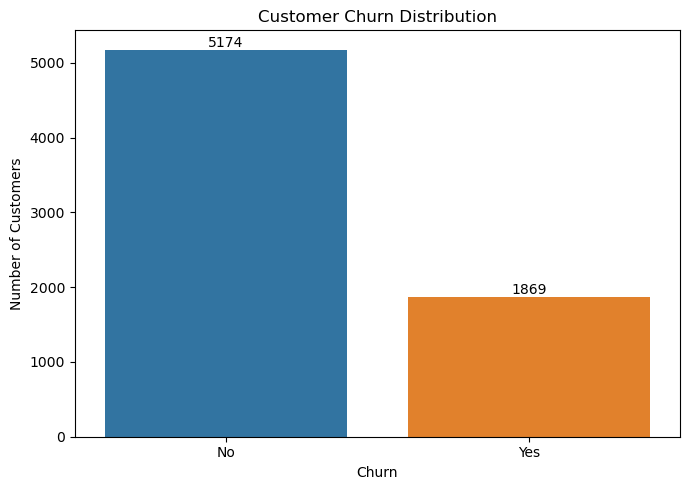

In [8]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(data=df_clean, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### 7. Churn percentage


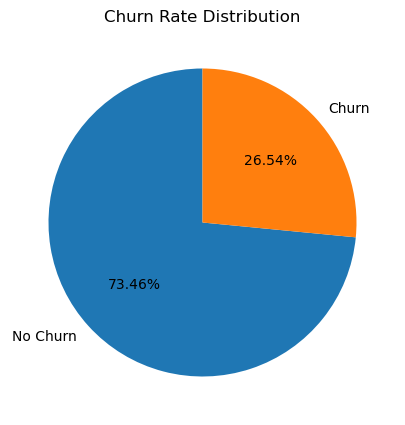

In [9]:
churn_rate = df_clean["Churn"].value_counts(normalize=True) * 100

labels = ["No Churn", "Churn"]
sizes = churn_rate.values

plt.figure(figsize=(7, 5))
plt.pie(sizes, labels=labels, autopct='%1.2f%%', startangle=90)
plt.title("Churn Rate Distribution")
plt.show()

### Key Insight

The dataset shows an imbalanced churn distribution, where non-churn customers account for a larger proportion than churn customers.  
This imbalance should be considered during model training and evaluation, especially when selecting metrics such as recall, F1-score, and ROC-AUC.

### 8. Churn Rate by Contract Type

In [10]:
contract_churn = (
    df_clean.groupby("Contract")["Churn"]
    .apply(lambda x: (x == "Yes").mean())
    .sort_values(ascending=False)
    .reset_index(name="ChurnRate")
)

contract_churn

,Contract,ChurnRate
0,Month-to-month,0.427097
1,One year,0.112695
2,Two year,0.028319


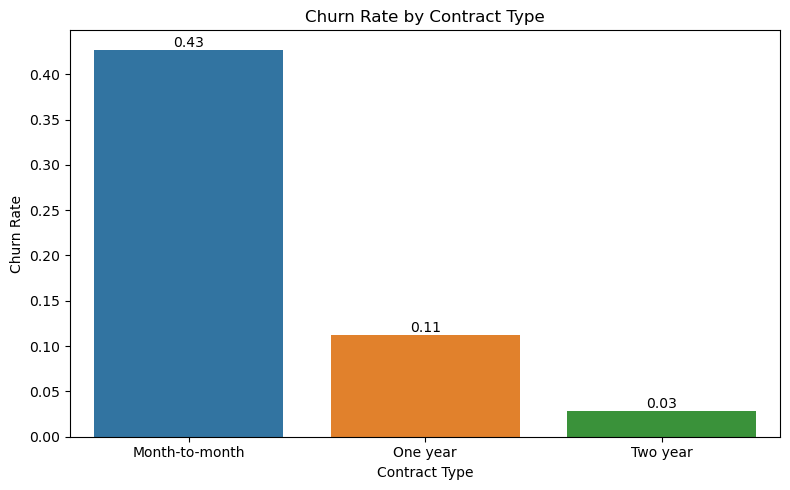

In [11]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(data=contract_churn, x="Contract", y="ChurnRate")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.tight_layout()
plt.show()

### Key Insight

Customers with month-to-month contracts tend to have a much higher churn rate compared to customers with one-year or two-year contracts.  
This suggests that long-term contracts may help improve customer retention.

### 9. Tenure group

In [12]:
df_clean["TenureGroup"] = pd.cut(
    df_clean["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12 months", "13-24 months", "25-48 months", "49-72 months"],
    include_lowest=True
)

tenure_churn = (
    df_clean.groupby("TenureGroup", observed=False)["Churn"]
    .apply(lambda x: (x == "Yes").mean())
    .reset_index(name="ChurnRate")
)

tenure_churn

,TenureGroup,ChurnRate
0,0-12 months,0.474382
1,13-24 months,0.287109
2,25-48 months,0.203890
3,49-72 months,0.095132


c:\Users\user\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


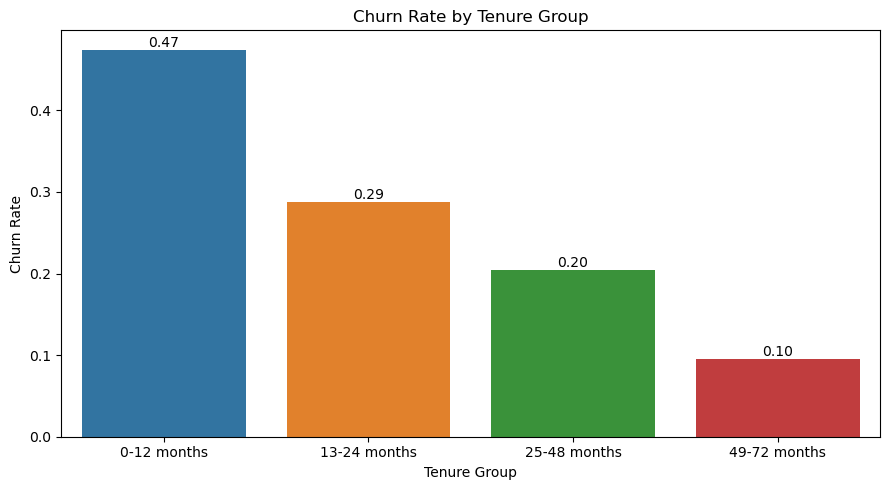

In [13]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(data=tenure_churn, x="TenureGroup", y="ChurnRate")

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.tight_layout()
plt.show()

### Key Insight

Customers with shorter tenure have a higher churn rate.  
This indicates that the early stage of the customer relationship is critical, and businesses should focus on onboarding, engagement, and early retention programs.

### 10. Churn Rate by Internet Service

In [14]:
internet_churn = (
    df_clean.groupby("InternetService")["Churn"]
    .apply(lambda x: (x == "Yes").mean())
    .sort_values(ascending=False)
    .reset_index(name="ChurnRate")
)

internet_churn

,InternetService,ChurnRate
0,Fiber optic,0.418928
1,DSL,0.189591
2,No,0.074050


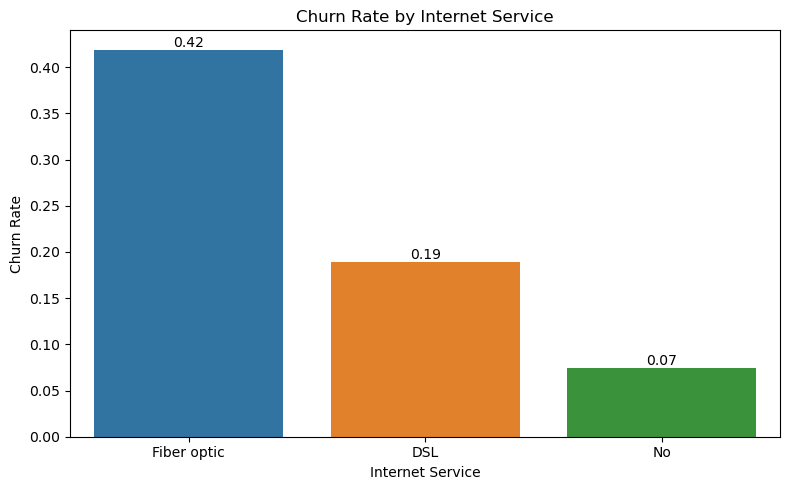

In [15]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(data=internet_churn, x="InternetService", y="ChurnRate")

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.tight_layout()
plt.show()

### Key Insight

Customers using fiber optic service tend to show a higher churn rate.  
This may indicate potential issues related to pricing, service expectations, or customer satisfaction.

### 11. Churn Rate by Payment Method


In [16]:
payment_churn = (
    df_clean.groupby("PaymentMethod")["Churn"]
    .apply(lambda x: (x == "Yes").mean())
    .sort_values(ascending=False)
    .reset_index(name="ChurnRate")
)

payment_churn

,PaymentMethod,ChurnRate
0,Electronic check,0.452854
1,Mailed check,0.191067
2,Bank transfer (automatic),0.167098
3,Credit card (automatic),0.152431


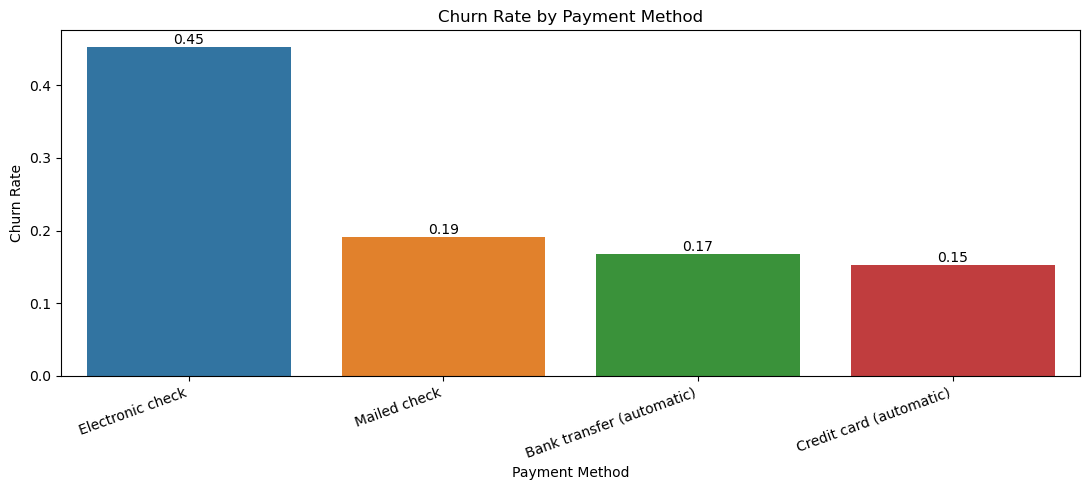

In [17]:
plt.figure(figsize=(11, 5))

ax = sns.barplot(data=payment_churn, x="PaymentMethod", y="ChurnRate")

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate")
plt.xticks(rotation=20, ha="right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.tight_layout()
plt.show()

### Key Insight

Customers using electronic check tend to have a higher churn rate compared to customers using automatic payment methods.  
This may suggest that automatic payment methods are associated with stronger customer retention.

### 12. Monthly Charges and Churn

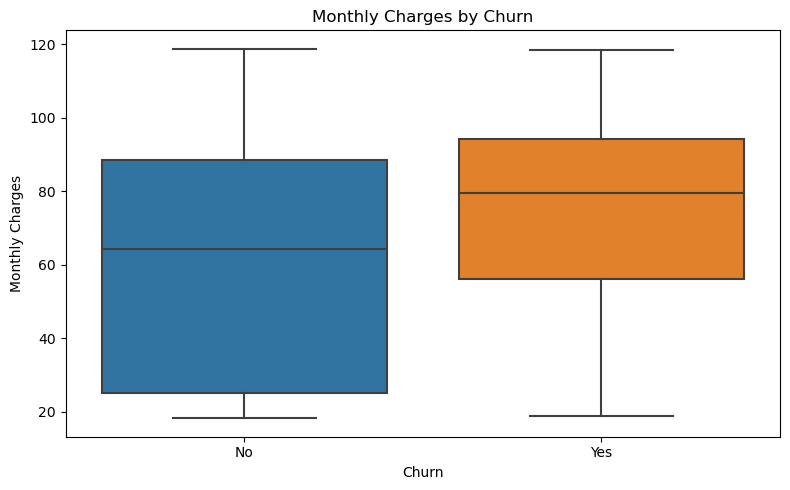

In [18]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df_clean, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.tight_layout()
plt.show()

In [20]:
# Average monthly charges by churn
df_clean.groupby("Churn")['MonthlyCharges'].mean().round(2)

Churn
No     61.27
Yes    74.44
Name: MonthlyCharges, dtype: float64

### Key Insight

Churn customers tend to have higher monthly charges on average.  
This suggests that pricing and perceived value may be important factors in customer churn.

### 13. Tenure and Churn

<function matplotlib.pyplot.show(close=None, block=None)>

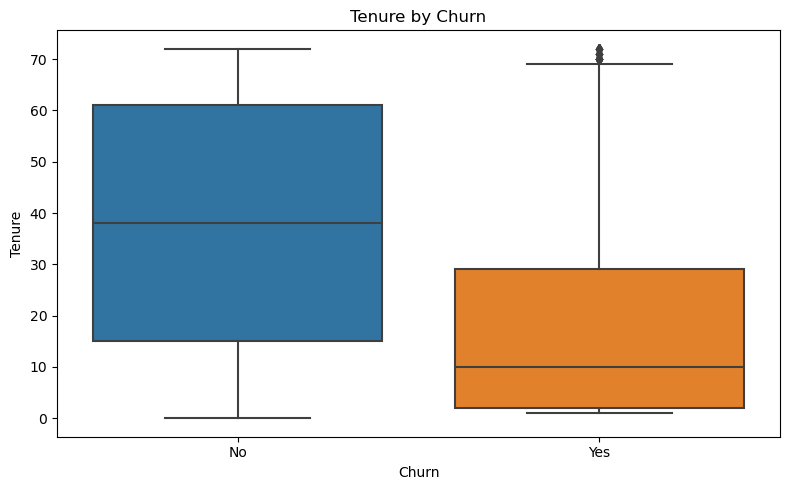

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df_clean, x= 'Churn', y='tenure')
plt.title('Tenure by Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure')
plt.tight_layout()

plt.show

In [23]:
df_clean.groupby('Churn')['tenure'].mean().round(2)

Churn
No     37.57
Yes    17.98
Name: tenure, dtype: float64

### Key Insight

Customers who churn tend to have lower average tenure.  
This reinforces the importance of early-stage customer engagement and retention actions.

### 14. Churn Rate by Support Services

In [24]:
support_features = ["OnlineSecurity", "TechSupport"]

for feature in support_features:
    churn_summary = (
        df_clean.groupby(feature)["Churn"]
        .apply(lambda x: (x == "Yes").mean())
        .sort_values(ascending=False)
        .reset_index(name="ChurnRate")
    )
    
    display(churn_summary)

,OnlineSecurity,ChurnRate
0,No,0.417667
1,Yes,0.146112
2,No internet service,0.074050


,TechSupport,ChurnRate
0,No,0.416355
1,Yes,0.151663
2,No internet service,0.074050


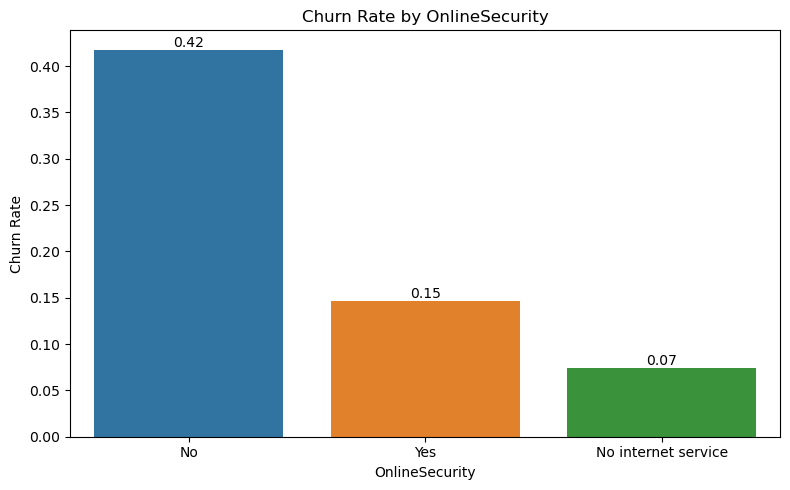

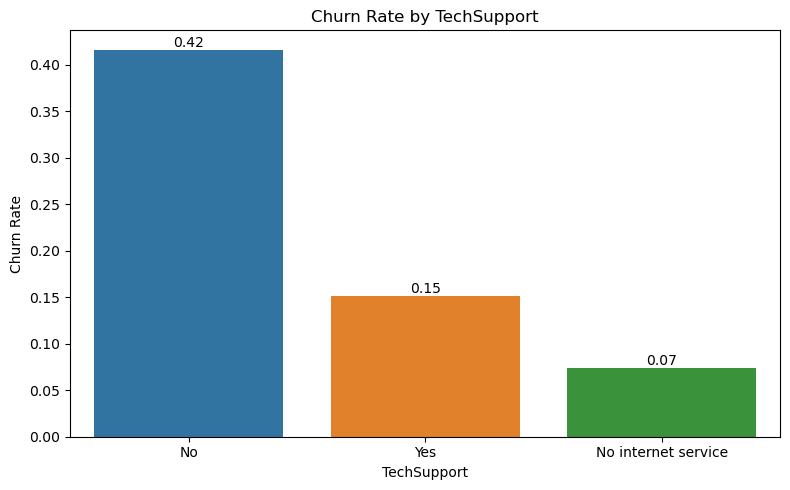

In [25]:
for feature in support_features:
    churn_summary = (
        df_clean.groupby(feature)["Churn"]
        .apply(lambda x: (x == "Yes").mean())
        .sort_values(ascending=False)
        .reset_index(name="ChurnRate")
    )

    plt.figure(figsize=(8, 5))
    
    ax = sns.barplot(data=churn_summary, x=feature, y="ChurnRate")
    
    plt.title(f"Churn Rate by {feature}")
    plt.xlabel(feature)
    plt.ylabel("Churn Rate")

    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f")

    plt.tight_layout()
    plt.show()

### Key Insight

Customers without support-related services such as Online Security or Tech Support tend to show higher churn risk.  
This suggests that service bundles and support features may play an important role in customer retention.

### 13. Correlation Analysis


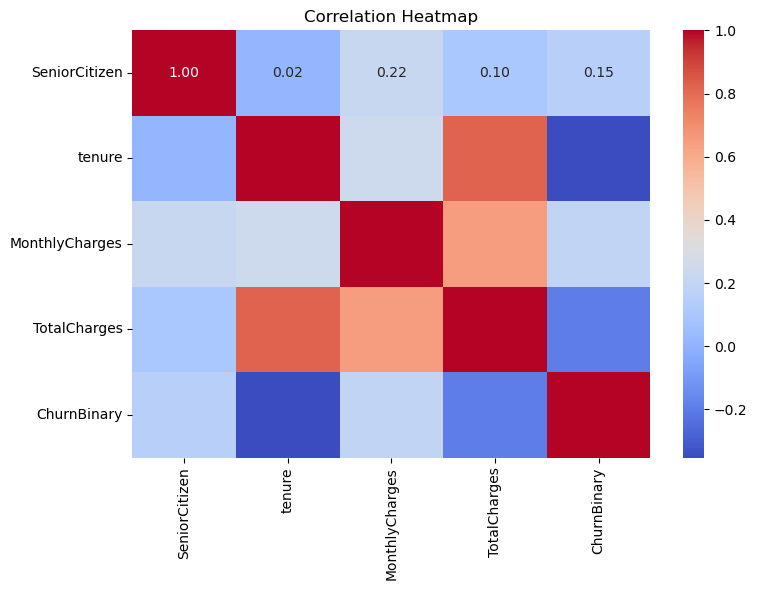

In [26]:
df_corr = df_clean.copy()
df_corr["ChurnBinary"] = df_corr["Churn"].map({"Yes": 1, "No": 0})

numerical_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges", "ChurnBinary"]

plt.figure(figsize=(8, 6))

sns.heatmap(
    df_corr[numerical_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

### Key Insight

Tenure has a negative relationship with churn, while monthly charges tend to show a positive relationship with churn.  
This means customers with shorter tenure and higher monthly charges may require more attention in retention strategies.

### 15. Business Recommendations

Based on the EDA findings, the following retention strategies can be considered:

- Provide targeted offers to customers with month-to-month contracts
- Improve onboarding and engagement for new customers with low tenure
- Review pricing and service quality for customers with high monthly charges
- Encourage customers to switch to automatic payment methods
- Promote support-related services such as Online Security and Tech Support
- Prioritize high-risk customer groups for proactive retention campaigns

These recommendations can help businesses reduce churn risk and improve customer lifetime value.

### 16. Conclusion

This exploratory data analysis provides a clear understanding of customer churn behavior in the Telco dataset.  
The findings suggest that contract type, tenure, monthly charges, payment method, internet service, and support-related services are important factors associated with churn.

These insights will be used in the next stages of the project, including data preprocessing, feature engineering, model training, model evaluation, and deployment.